--- Loading Dataset ---
Train shapes: X=(1769, 10, 1), y=(1769,)
Test shapes: X=(443, 10, 1), y=(443,)

--- Training LSTM Model ---
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0133 - val_loss: 1.0251e-04
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0040 - val_loss: 1.9921e-05
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0037 - val_loss: 1.7344e-04
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0036 - val_loss: 2.4876e-04
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0040 - val_loss: 3.9553e-05
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0032 - val_loss: 2.3950e-04
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0034 - val_loss: 3.6009e-06
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0030 - val_loss: 6.0668e-05
Epoch 9/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0027 - val_loss: 1.8760e-05
Epoch 10/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0030 - val_loss: 2.7216e-06
Epoch 11/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0025 - val_loss: 8.8598e-05
Epoch 12/15
56/56 ━━━━━━━━━━━━

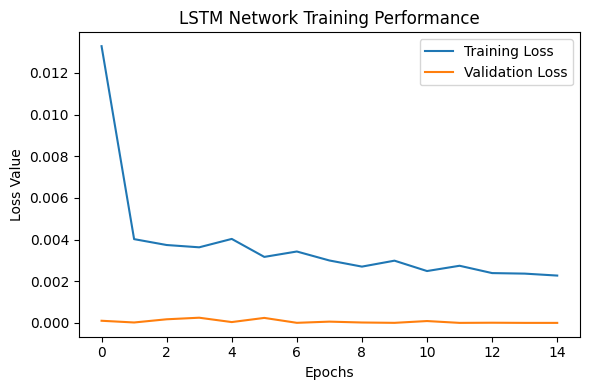

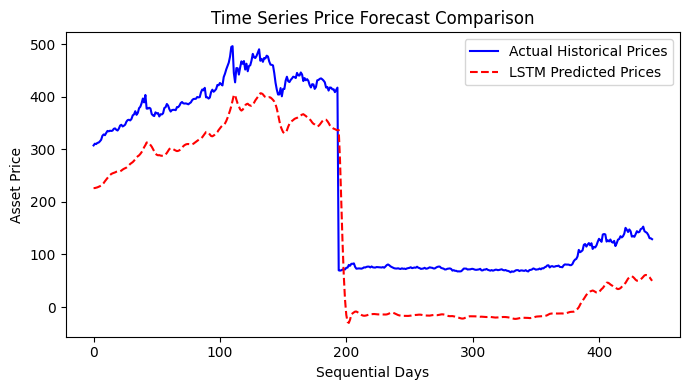

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ==========================================
# 1. Load Data & Create Fake Date Column
# ==========================================
print("--- Loading Dataset ---")
df = pd.read_csv('cleaned_data.csv')

# Time series models need sequential dates. If your data doesn't have a date column,
# we create a dummy timeline starting from Jan 1st, 2024 to make the functions work.
if 'Date' not in df.columns:
    df['Date'] = pd.date_range(start='2024-01-01', periods=len(df), freq='D')

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# We will use 'Current_Price' as our continuous time-series column to forecast
price_data = df[['Current_Price']].values

# ==========================================
# 2. MinMax Feature Scaling
# ==========================================
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_price = scaler.fit_transform(price_data)

# ==========================================
# 3. Create Sliding Windows (Lookback = 10 days)
# ==========================================
# To predict day 11's price, the LSTM needs to read the previous 10 days of prices.
X_lstm, y_lstm = [], []
lookback = 10

for i in range(lookback, len(scaled_price)):
    X_lstm.append(scaled_price[i-lookback:i, 0])
    y_lstm.append(scaled_price[i, 0])

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# Reshape input to be [samples, time steps, features] required by LSTM layers
X_lstm = np.reshape(X_lstm, (X_lstm.shape[0], X_lstm.shape[1], 1))

# ==========================================
# 4. Train-Test Sequential Split (80% Train, 20% Test)
# ==========================================
# In time-series data, we DO NOT randomly shuffle data because it breaks the chronological timeline.
split_point = int(len(X_lstm) * 0.8)

X_train, X_test = X_lstm[:split_point], X_lstm[split_point:]
y_train, y_test = y_lstm[:split_point], y_lstm[split_point:]

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}\n")

# ==========================================
# 5. Build and Train the LSTM Neural Network
# ==========================================
model = Sequential()

# First LSTM Layer with Dropout regularizer to prevent overfitting
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Second LSTM Layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Final Dense Output layer to predict the single continuous price scalar
model.add(Dense(units=1))

# Compile using Adam optimizer and Mean Squared Error loss tracking metric
model.compile(optimizer='adam', loss='mean_squared_error')

print("--- Training LSTM Model ---")
history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# ==========================================
# 6. Evaluation and Inverting Predictions
# ==========================================
predictions_scaled = model.predict(X_test)

# Convert scaled prices back into real original dollar value coordinates
predictions = scaler.inverse_transform(predictions_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

# Quantify performance error margins
mse = np.mean((predictions - y_test_real) ** 2)
rmse = np.sqrt(mse)
print(f"\nTime Series Model Performance:\n  MSE Error: {mse:.4f}\n  RMSE Error: {rmse:.4f}")

# ==========================================
# 7. Generate Output Forecasting Graphics
# ==========================================
# Plot training loss graph
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Network Training Performance')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_training_loss.png')
plt.show()

# Plot actual vs predicted stock prices
plt.figure(figsize=(7, 4))
plt.plot(y_test_real, label='Actual Historical Prices', color='blue')
plt.plot(predictions, label='LSTM Predicted Prices', color='red', linestyle='--')
plt.title('Time Series Price Forecast Comparison')
plt.xlabel('Sequential Days')
plt.ylabel('Asset Price')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_price_forecast.png')
plt.show()